In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("bodyfat.csv")
df.head()

,Density,BodyFat,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
0,1.0708,12.3,23,154.25,67.75,36.2,93.1,85.2,94.5,59.0,37.3,21.9,32.0,27.4,17.1
1,1.0853,6.1,22,173.25,72.25,38.5,93.6,83.0,98.7,58.7,37.3,23.4,30.5,28.9,18.2
2,1.0414,25.3,22,154.00,66.25,34.0,95.8,87.9,99.2,59.6,38.9,24.0,28.8,25.2,16.6
3,1.0751,10.4,26,184.75,72.25,37.4,101.8,86.4,101.2,60.1,37.3,22.8,32.4,29.4,18.2
4,1.0340,28.7,24,184.25,71.25,34.4,97.3,100.0,101.9,63.2,42.2,24.0,32.2,27.7,17.7


In [20]:
df.isnull().sum()

Density    0
BodyFat    0
Age        0
Weight     0
Height     0
Neck       0
Chest      0
Abdomen    0
Hip        0
Thigh      0
Knee       0
Ankle      0
Biceps     0
Forearm    0
Wrist      0
dtype: int64

In [3]:
df.dropna(axis=0, inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252 entries, 0 to 251
Data columns (total 15 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Density  252 non-null    float64
 1   BodyFat  252 non-null    float64
 2   Age      252 non-null    int64  
 3   Weight   252 non-null    float64
 4   Height   252 non-null    float64
 5   Neck     252 non-null    float64
 6   Chest    252 non-null    float64
 7   Abdomen  252 non-null    float64
 8   Hip      252 non-null    float64
 9   Thigh    252 non-null    float64
 10  Knee     252 non-null    float64
 11  Ankle    252 non-null    float64
 12  Biceps   252 non-null    float64
 13  Forearm  252 non-null    float64
 14  Wrist    252 non-null    float64
dtypes: float64(14), int64(1)
memory usage: 29.7 KB


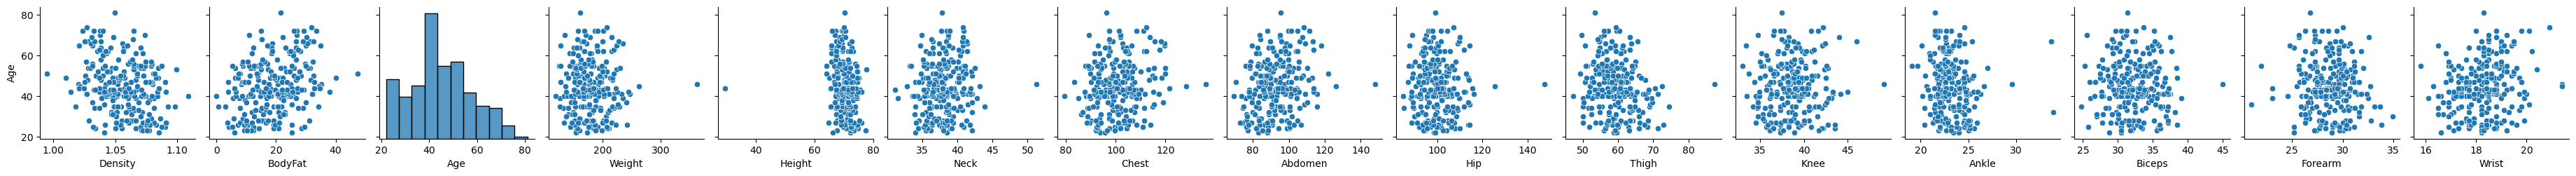

In [ ]:
#Exploración de datos
sns.pairplot(df, y_vars = "Age")

<Axes: >

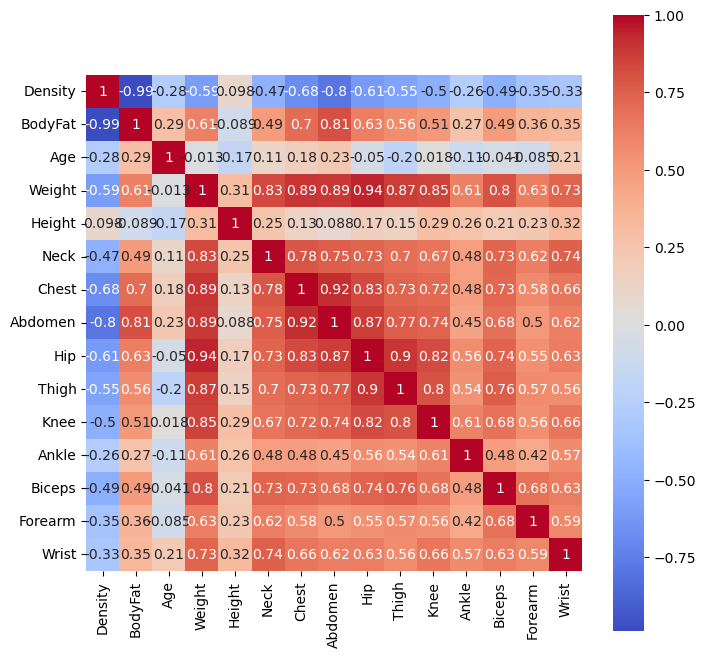

In [7]:
plt.figure(figsize=(8,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, square= True, cmap="coolwarm")

Vemos el rendimiento para combinaciones de la edad con el peso

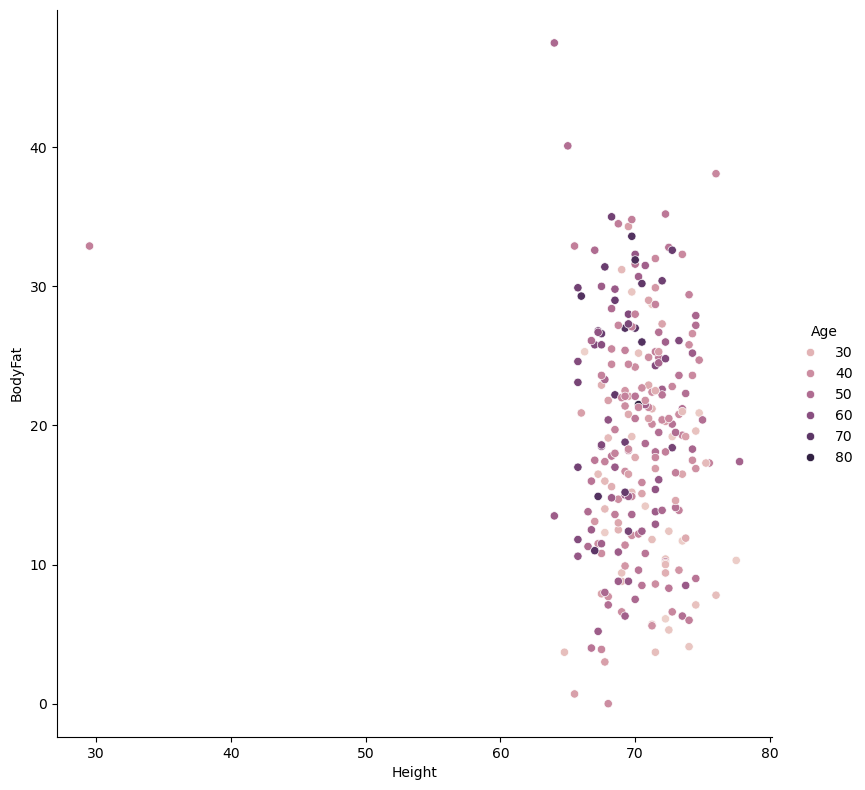

In [8]:
sns.pairplot(data=df, y_vars= "BodyFat", x_vars= "Height", hue = "Age", height=8)

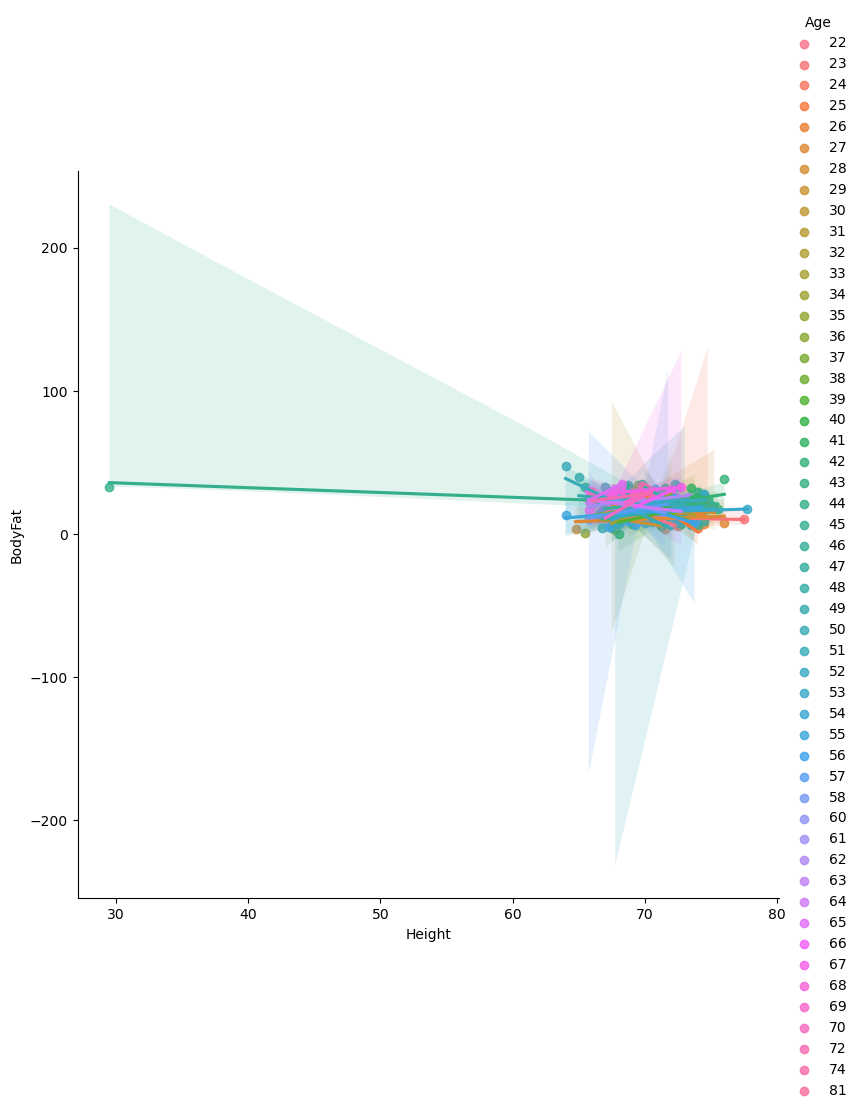

In [10]:
sns.lmplot(data=df, y='BodyFat', x='Height', hue='Age', height=8)

Regresión Lineal

In [12]:
import statsmodels.api as sm
x = np.array(df.Height)
y = np.array(df.BodyFat)

In [13]:
X = sm.add_constant(x)
X

array([[ 1.  , 67.75],
       [ 1.  , 72.25],
       [ 1.  , 66.25],
       [ 1.  , 72.25],
       [ 1.  , 71.25],
       [ 1.  , 74.75],
       [ 1.  , 69.75],
       [ 1.  , 72.5 ],
       [ 1.  , 74.  ],
       [ 1.  , 73.5 ],
       [ 1.  , 74.5 ],
       [ 1.  , 76.  ],
       [ 1.  , 69.5 ],
       [ 1.  , 71.25],
       [ 1.  , 69.5 ],
       [ 1.  , 66.  ],
       [ 1.  , 71.  ],
       [ 1.  , 71.  ],
       [ 1.  , 67.75],
       [ 1.  , 73.5 ],
       [ 1.  , 68.  ],
       [ 1.  , 69.75],
       [ 1.  , 68.25],
       [ 1.  , 70.  ],
       [ 1.  , 67.75],
       [ 1.  , 71.5 ],
       [ 1.  , 67.5 ],
       [ 1.  , 67.5 ],
       [ 1.  , 64.75],
       [ 1.  , 69.  ],
       [ 1.  , 73.75],
       [ 1.  , 71.25],
       [ 1.  , 71.25],
       [ 1.  , 71.  ],
       [ 1.  , 73.5 ],
       [ 1.  , 65.  ],
       [ 1.  , 70.  ],
       [ 1.  , 68.25],
       [ 1.  , 72.25],
       [ 1.  , 67.  ],
       [ 1.  , 68.75],
       [ 1.  , 29.5 ],
       [ 1.  , 70.  ],
       [ 1.

In [14]:
#Definimos el tipo de modelo estadistico (aún no lo entrenamos), les damos las variables que usaremos, pero no calcula nada
#variable y = lo que queremos predecir
#variable x = predictoras
regresion_sm = sm.OLS(y,X)
# Es un objeto con los resultados de ajuste que contiene, coeficientes, R^2, p-valores, intervalos de confianza
results_sm = regresion_sm.fit()
#Muestra un resumen del modelo ajustado
results_sm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     2.019
Date:                Tue, 04 Nov 2025   Prob (F-statistic):              0.157
Time:                        08:54:15   Log-Likelihood:                -891.43
No. Observations:                 252   AIC:                             1787.
Df Residuals:                     250   BIC:                             1794.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         33.4945     10.110      3.313      0.001      13.584      53.405
x1            -0.2045      0.144     -1.421      0.157      -0.488       0.079
==============================================================================
Omnibus:                        2.343   Durbin-Watson:                   1.474
Prob(Omnibus):                  0.310   Jarque-Bera (JB):                1.995
Skew:                           0.099   Prob(JB):                        0.369
Kurtosis:                       2.611   Cond. No.                     1.35e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.35e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [15]:
#Sacamos los coeficientes beta
beta0 = results_sm.params[0]
beta1 = results_sm.params[1]
beta0, beta1

(np.float64(33.49449378919043), np.float64(-0.20447531805266456))

Visualizamos los datos y sus predicciones

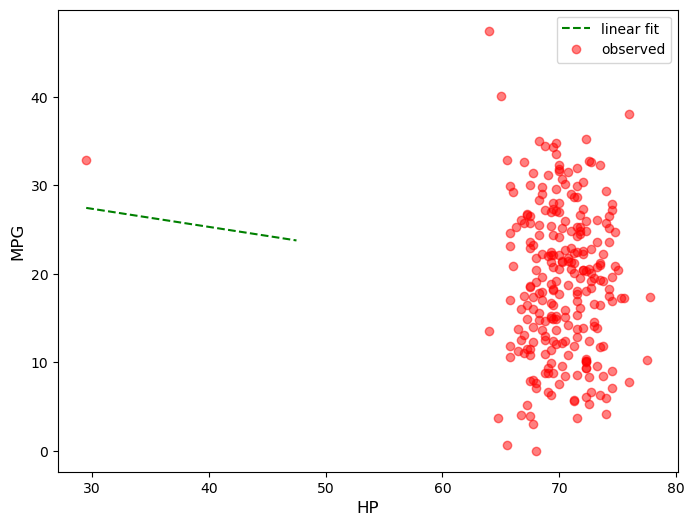

In [16]:
fig, ax = plt.subplots(1,1, figsize=(8,6))

grid = np.linspace(np.min(df.Height), np.max(df.BodyFat), 100)

y_fit = beta0 + beta1*grid

ax.plot(grid, y_fit, '--', color='g', label='linear fit')
ax.plot(df.Height, df.BodyFat, 'o', color='red', alpha=0.5, label='observed') 
ax.set_xlabel("HP", fontsize=12)
ax.set_ylabel("MPG", fontsize=12)
ax.legend();

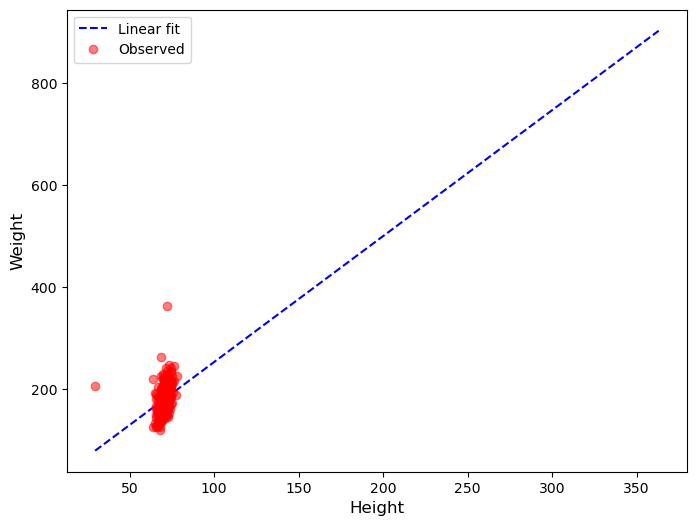

In [18]:
# preparar datos
x = np.array(df.Height)
y = np.array(df.Weight)
X = sm.add_constant(x)

# realizar modelo
regresion_sm = sm.OLS(y, X)
results_sm = regresion_sm.fit()

# extraer par'ametros
beta0 = results_sm.params[0]
beta1 = results_sm.params[1]

# visualizar
fig, ax = plt.subplots(1,1, figsize=(8,6))
grid = np.linspace(np.min(df.Height), np.max(df.Weight), 100)
y_fit_lineal = beta0 + beta1*grid

ax.plot(grid, y_fit_lineal, '--', color='b', label='Linear fit')
ax.plot(df.Height, df.Weight, 'o', color='r', alpha=0.5, label='Observed') 

ax.set_xlabel("Height", fontsize=12)
ax.set_ylabel("Weight", fontsize=12)
ax.legend()

In [19]:
results_sm.rsquared

np.float64(0.09503565825166782)

Regresión Polinomial